In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



C:\Users\nandi\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv(r"C:\Users\nandi\Mrinmoy_python\AI_ML\YuvaIntern\WEEK-6\retail_store_inventory.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,73100,731,2022-01-01,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store ID,73100,5,S001,14620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,73100,20,P0001,3655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,73100,5,Furniture,14699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,73100,4,East,18349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,73100.0,NaN,NaN,NaN,274.469877,129.949514,50.0,162.0,273.0,387.0,500.0
Units Sold,73100.0,NaN,NaN,NaN,136.46487,108.919406,0.0,49.0,107.0,203.0,499.0
Units Ordered,73100.0,NaN,NaN,NaN,110.004473,52.277448,20.0,65.0,110.0,155.0,200.0
Demand Forecast,73100.0,NaN,NaN,NaN,141.49472,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,NaN,NaN,NaN,55.135108,26.021945,10.0,32.65,55.05,77.86,100.0


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates()
df = df.dropna()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (73100, 15)


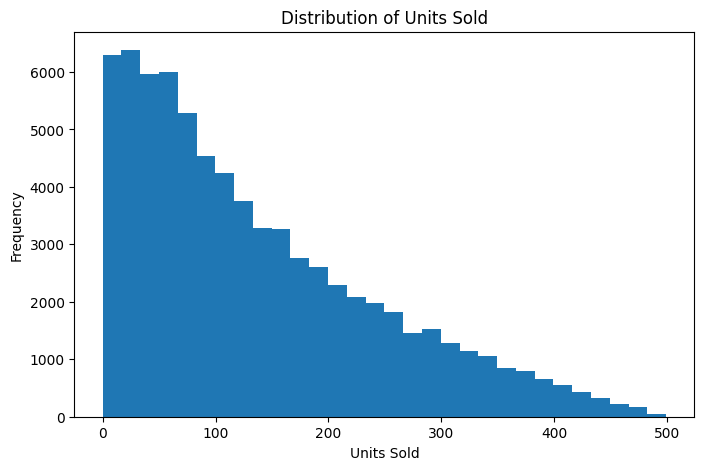

In [7]:
plt.figure(figsize=(8, 5))
df["Units Sold"].plot(kind="hist", bins=30)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

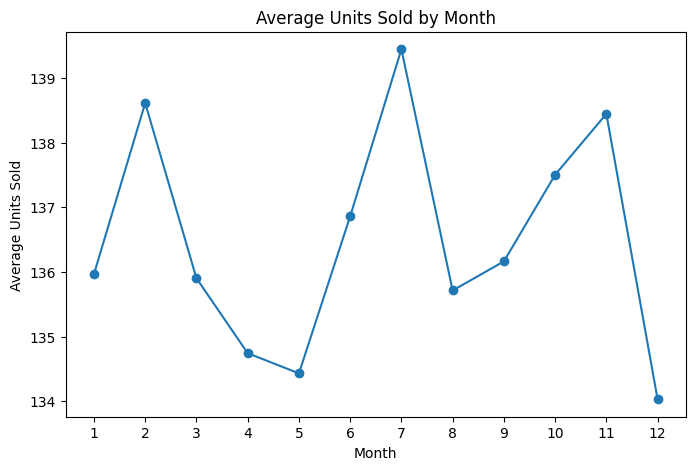

In [8]:
df["Month"] = df["Date"].dt.month
monthly_sales = df.groupby("Month")["Units Sold"].mean()

plt.figure(figsize=(8, 5))
monthly_sales.plot(marker="o")
plt.title("Average Units Sold by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(1, 13))
plt.show()

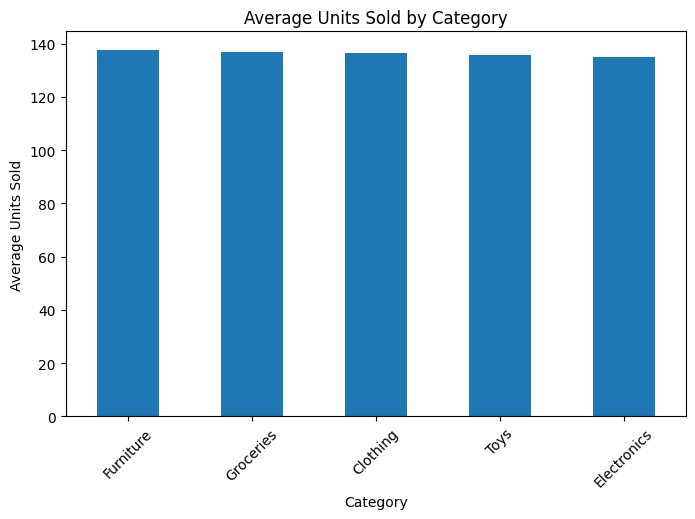

In [9]:
category_sales = df.groupby("Category")["Units Sold"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Average Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

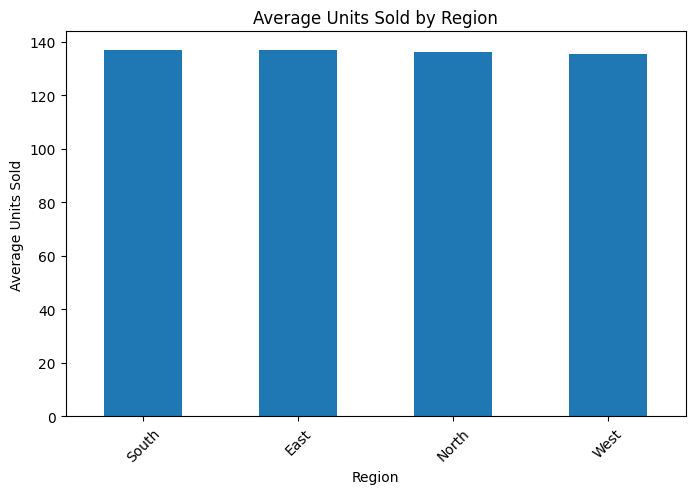

In [10]:
region_sales = df.groupby("Region")["Units Sold"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.title("Average Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.show()

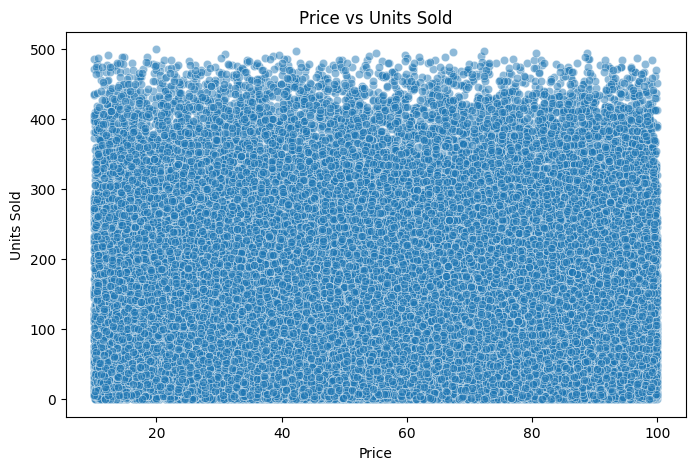

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Price", y="Units Sold", alpha=0.5)
plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()

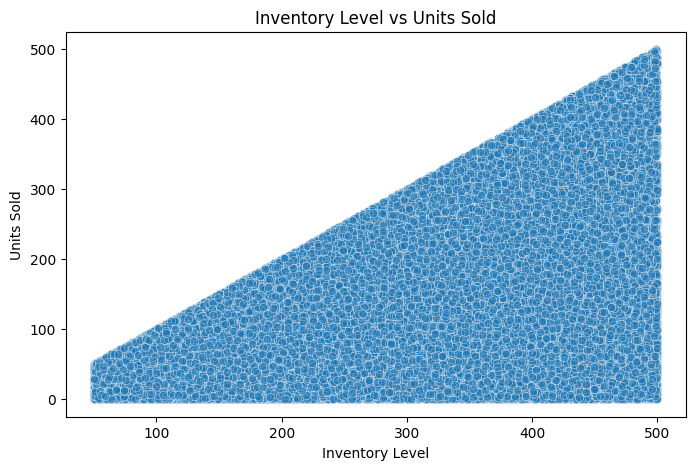

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Inventory Level", y="Units Sold", alpha=0.5)
plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.show()

In [13]:
df["DayOfWeek"] = df["Date"].dt.dayofweek

features = [
    "Inventory Level", "Units Ordered", "Price", "Discount",
    "Holiday/Promotion", "Competitor Pricing", "Category", "Region",
    "Weather Condition", "Seasonality", "Month", "DayOfWeek"
]

target = "Units Sold"
X = df[features]
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (73100, 12)
Target: (73100,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (58480, 12)
Testing data: (14620, 12)


In [15]:
categorical_features = [
    "Category", "Region", "Weather Condition", "Seasonality"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [16]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [17]:
random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)
rf_pred = random_forest.predict(X_test)

In [18]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2}

results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Random Forest", y_test, rf_pred)
])

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,68.934962,88.068518,0.344908
1,Random Forest,69.663663,89.567769,0.322414


In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred
})
comparison.head(10)

,Actual,Linear Regression,Random Forest
0,138,112.601562,128.51
1,105,99.289062,130.16
2,70,71.987793,54.22
3,105,175.296387,179.83
4,76,74.991211,79.96
5,206,186.592285,168.77
6,87,55.564941,61.59
7,53,229.603027,234.06
8,129,67.518066,76.15
9,55,64.240723,70.30


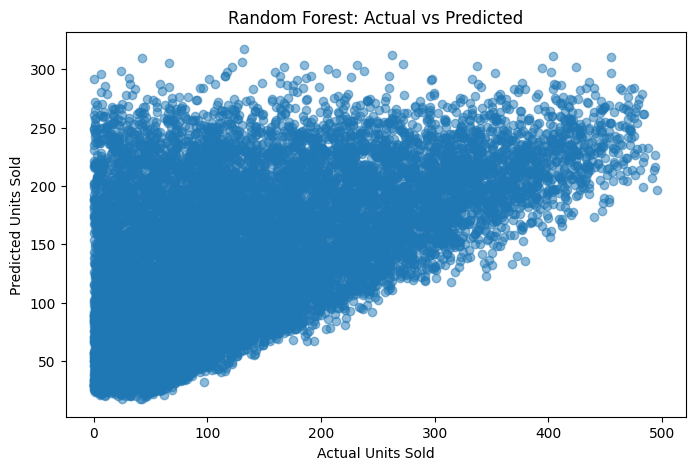

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

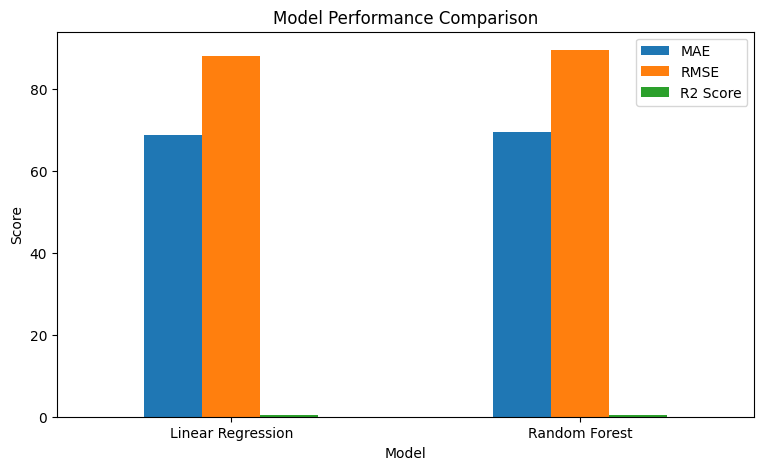

In [21]:
results.set_index("Model")[["MAE", "RMSE", "R2 Score"]].plot(
    kind="bar", figsize=(9, 5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## 16. Business Insights


The analysis can help a retail business understand sales differences across categories and regions, examine the relationship between price, inventory and units sold, and assess whether calendar and seasonal information contributes to prediction.
